In [41]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from piemd import PIEMD
from base_classes import Source, DiskSource
import scipy as sp
from PIL import Image

# Testing Gaussian psf vs Hubble psf from literature

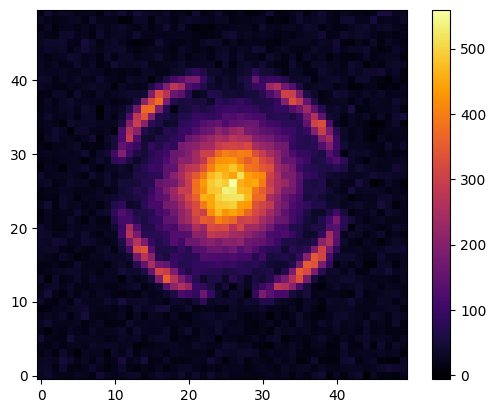

In [42]:
src = DiskSource(1000, 10)
df = PIEMD(src, theta_E=300, q=0.9, phi=np.pi/4, s=10)

img = df.generate_hubble_image(psf='gaussian', lens='gaussian')
plt.imshow(img, cmap='inferno', origin='lower')
plt.colorbar()
plt.show()

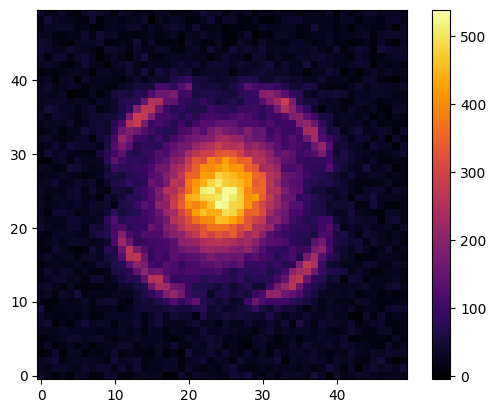

In [43]:
src = DiskSource(1000, 10)
df = PIEMD(src, theta_E=300, q=0.9, phi=np.pi/4, s=10)

img = df.generate_hubble_image(psf='hubble', lens='gaussian')
plt.imshow(img, cmap='inferno', origin='lower')
plt.colorbar()
plt.show()

# Testing Sercic vs Gaussian Profiles

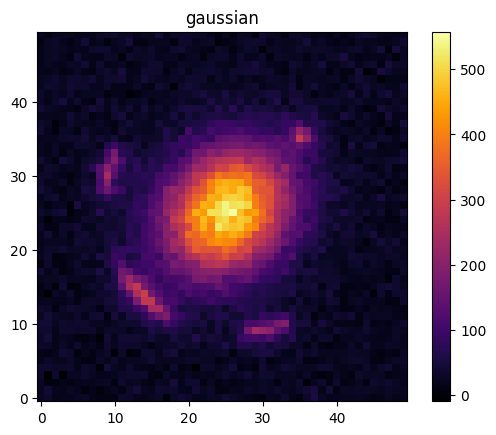

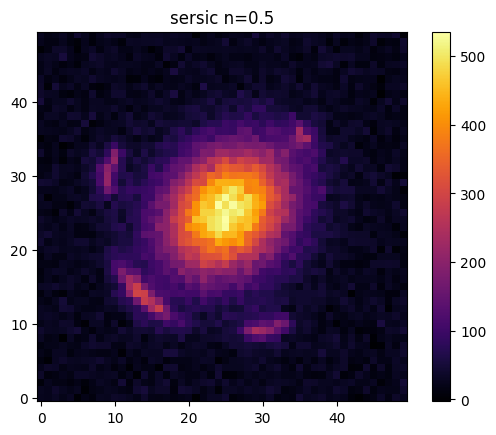

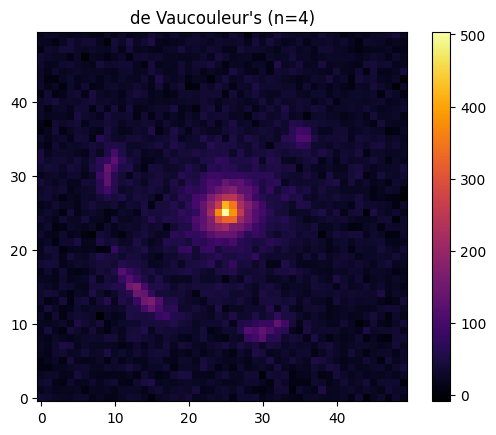

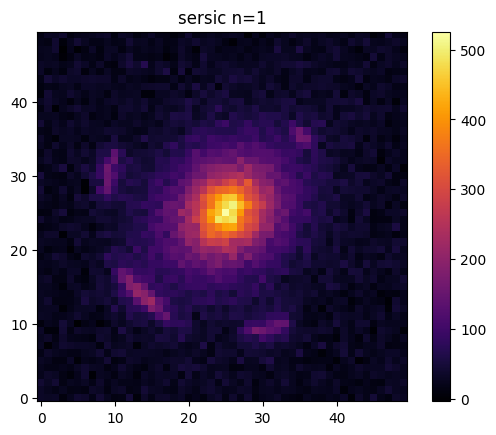

In [44]:
src = DiskSource(1000, 10)
df = PIEMD(src, theta_E=300, q=0.8, phi=np.pi/4, s=10)
df.align_lens(cx=515, cy=515)

# gaussian
img = df.generate_hubble_image(psf='hubble', n=2, lens='gaussian')
plt.imshow(img, cmap='inferno', origin='lower')
plt.colorbar()
plt.title("gaussian")
plt.show()

# should be the same distribution as gaussian
img = df.generate_hubble_image(psf='hubble', lens='sersic', R_e=120, n=0.5, I_lens=0.5)
plt.imshow(img, cmap='inferno', origin='lower')
plt.colorbar()
plt.title("sersic n=0.5")
plt.show()

# de Vaucouleur's
img = df.generate_hubble_image(psf='hubble', lens='sersic', R_e=120, n=4, I_lens=0.1)
plt.imshow(img, cmap='inferno', origin='lower')
plt.title("de Vaucouleur's (n=4)")
plt.colorbar()
plt.show()

# something else
img = df.generate_hubble_image(psf='hubble', lens='sersic', R_e=120, n=1, I_lens=0.4)
plt.imshow(img, cmap='inferno', origin='lower')
plt.colorbar()
plt.title("sersic n=1")
plt.show()

# Now lets try a sersic core model
https://iopscience.iop.org/article/10.1086/382712/pdf

In [45]:
%matplotlib inline
import matplotlib.pyplot as plt

In [46]:
# src = DiskSource(1000, 10)
df = PIEMD(src, theta_E=400, q=0.8, phi=np.pi/4, s=50)
df.align_source(cx=473, cy=525)

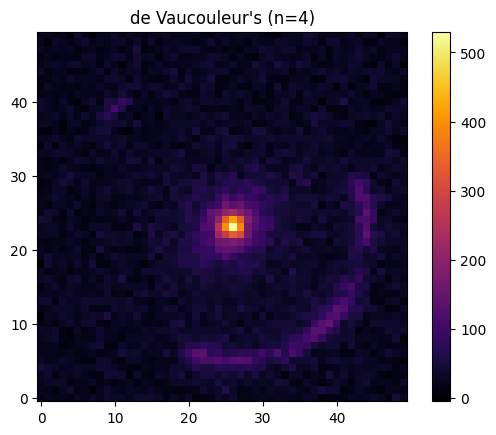

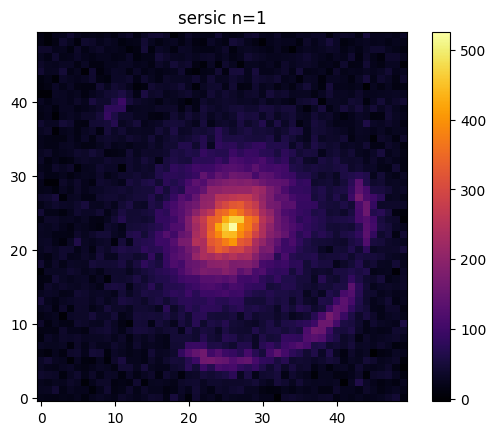

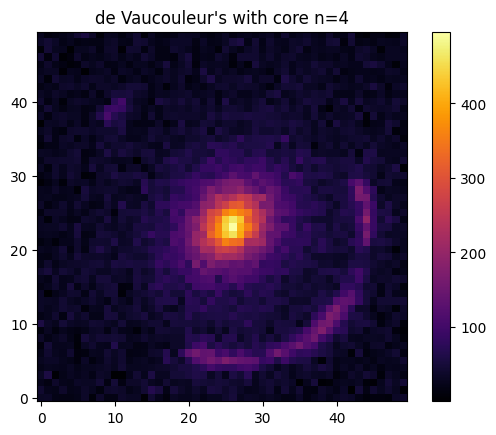

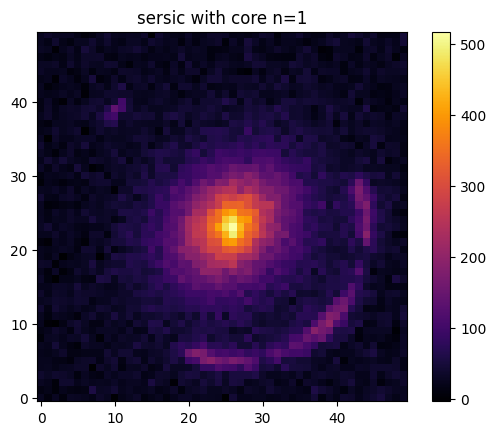

In [47]:
# de Vaucouleur's
img = df.generate_hubble_image(psf='hubble', lens='sersic', R_e=120, n=4, I_lens=0.1)
plt.imshow(img, cmap='inferno', origin='lower')
plt.title("de Vaucouleur's (n=4)")
plt.colorbar()
plt.show()

# something else
img = df.generate_hubble_image(psf='hubble', lens='sersic', R_e=120, n=1, I_lens=0.4)
plt.imshow(img, cmap='inferno', origin='lower')
plt.colorbar()
plt.title("sersic n=1")
plt.show()

# de Vaucouleur's with core
img = df.generate_hubble_image(psf='hubble', lens='sersic_core', R_e=120, n=4, I_lens=1)
plt.imshow(img, cmap='inferno', origin='lower')
plt.colorbar()
plt.title("de Vaucouleur's with core n=4")
plt.show()

# something else with core
img = df.generate_hubble_image(psf='hubble', lens='sersic_core', R_e=120, n=1, I_lens=1)
plt.imshow(img, cmap='inferno', origin='lower')
plt.colorbar()
plt.title("sersic with core n=1")
plt.show()



# What about a double source plane?

In [48]:
%matplotlib inline
import matplotlib.pyplot as plt

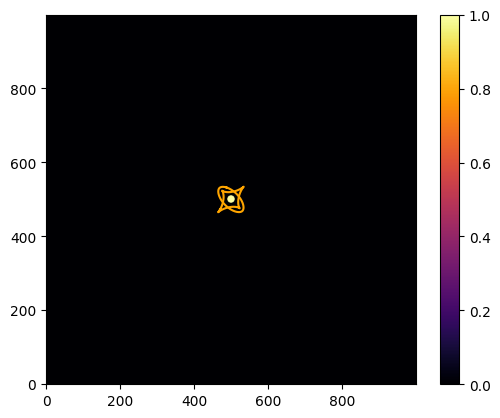

In [49]:
src1 = DiskSource(1000, 10)
df1 = PIEMD(src1, theta_E=100, s=30, q=0.6, phi=np.pi/4)
df1.plot_source(caustics=True)

In [50]:
%matplotlib inline
import matplotlib.pyplot as plt

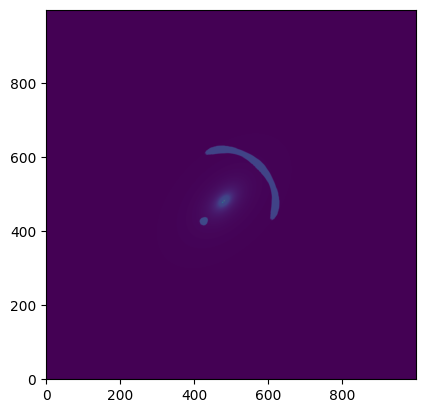

In [51]:
src1 = DiskSource(1000, 10)
df1 = PIEMD(src1, theta_E=100, s=10, q=0.6, phi=np.pi/4)
df1.align_source(518,518)
arr2 = df1.generate_image(lens='sersic_core')
plt.imshow(arr2, origin='lower')
plt.show()

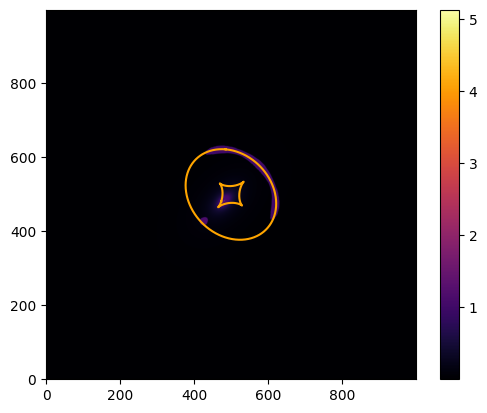

In [52]:
df2 = PIEMD(Source(arr2), theta_E=280, s=40, q=0.8, phi=np.pi/4)
df2.plot_source(caustics=True)

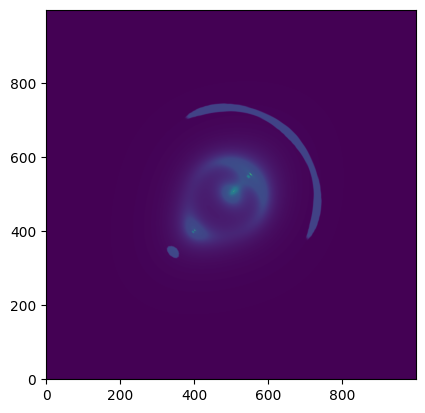

In [53]:
df2 = PIEMD(Source(arr2), theta_E=110, s=20, q=0.8, phi=-np.pi/4)
arr3 = df2.generate_image(lens='sersic_core')
plt.imshow(arr3, origin='lower')
plt.savefig("figures_out/double_lens.png")
plt.show()

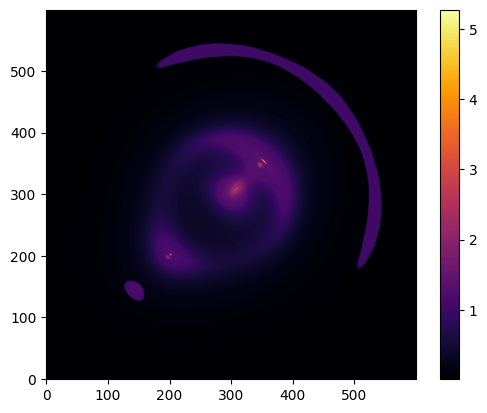

In [54]:
arr3 = arr3[200:800,200:800]
plt.imshow(arr3, origin='lower', cmap='inferno')
plt.colorbar()
plt.show()
df2.set_image(arr3)

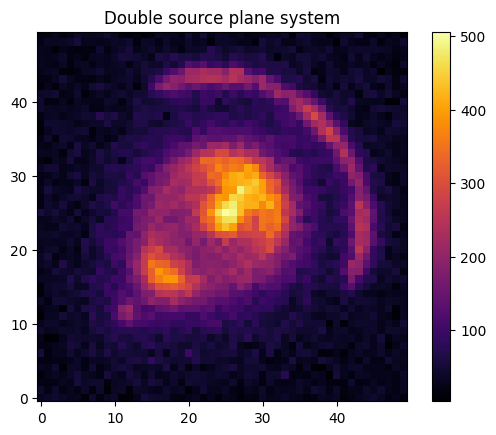

In [56]:
img = df2.generate_hubble_image(psf='hubble', lens='none', R_e=50, n=4, I_lens=1)
plt.imshow(img, cmap='inferno', origin='lower')
plt.colorbar()
plt.title("Double source plane system")
plt.show()